<a href="https://colab.research.google.com/github/Markwema86/Safaricom-Valuation-as-of-June-2026/blob/main/Safaricom_Valuation_as_of_June_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Valuation
The Core Question Every Investor Asks

Price tells what the market thinks a company is worth. Valuation tells you what it actually is worth. The gap between the two is where investment returns come from.

Three methods. Each answers a slightly different question:

**VALUATION METHODS**
1. **EV/EBITDA Multiple**

"How does the market price compare to earnings before financing costs?"

**Used by:** PE firms, M&A advisors

2. **P/E Ratio**

"How much are investors paying per    shilling of profit?"

**Used by:** Public market investors

3. **DCF - Discounted Cash Flow**

"What is the company worth based on all future cash flows?"

**Used by:** Long-term fundamental investors

####Enterprise Value
Before we calculate any multiple, we need Enterprise Value (EV).
Market cap is what equity investors paid. But a company also has debt - which an acquirer would inherit. EV captures the full picture.

> EV = Market Cap + Total Debt - Cash



In [2]:
# Safaricom valuation inputs
# Filled in from annual report readings

market_cap      = 1.25e12   # KES 1.25 trillion
total_debt      = 159400000000   # KES - from balance sheet
cash            = 30450000000    # KES - from balance sheet
ebitda          = 172150900000   # KES - from income statement
net_profit      = 45757200000    # KES - from income statement
free_cash_flow  = 64662700000    # KES - from cash flow analysis
revenue         = 388688900000   # KES - from income statement
shares_outstanding = 40065400000 # from annual report cover page

# Convert everything to billions for readability
def to_billions(x):
    return x / 1e9

# Enterprise Value
ev = market_cap + total_debt - cash

print("=== SAFARICOM ENTERPRISE VALUE ===\n")
print(f"Market Capitalisation: KES {to_billions(market_cap):.1f}B")
print(f"(+) Total Debt:        KES {to_billions(total_debt):.1f}B")
print(f"(-) Cash:              KES {to_billions(cash):.1f}B")
print(f"{'─'*40}")
print(f"Enterprise Value:      KES {to_billions(ev):.1f}B")
print(f"\nInterpretation: To acquire Safaricom outright,")
print(f"an investor would effectively pay KES {to_billions(ev):.1f}B")
print(f"— market cap plus inherited debt minus cash received.")

=== SAFARICOM ENTERPRISE VALUE ===

Market Capitalisation: KES 1250.0B
(+) Total Debt:        KES 159.4B
(-) Cash:              KES 30.4B
────────────────────────────────────────
Enterprise Value:      KES 1379.0B

Interpretation: To acquire Safaricom outright,
an investor would effectively pay KES 1379.0B
— market cap plus inherited debt minus cash received.


####EV/EBITDA Multiple
The primary valuation metric in PE and M&A.

In [3]:
# EV/EBITDA
ev_ebitda = ev / ebitda

# Industry benchmarks for African telecoms
# Global telecom average: 6-8x
# Premium African operators: 8-12x
# Global tech/fintech premium: 15-25x

print("=== EV/EBITDA VALUATION ===\n")
print(f"Enterprise Value:  KES {to_billions(ev):.1f}B")
print(f"EBITDA:            KES {to_billions(ebitda):.1f}B")
print(f"EV/EBITDA Multiple: {ev_ebitda:.1f}x")

print(f"\n{'─'*40}")
print("BENCHMARK COMPARISON:")
print(f"  Global Telecom Average:    6-8x")
print(f"  Premium African Operator:  8-12x")
print(f"  Fintech Premium:           15-25x")
print(f"  Safaricom:                 {ev_ebitda:.1f}x")
print(f"{'─'*40}")

if ev_ebitda <= 8:
    print("VERDICT: CHEAP - trading below telecom average")
    print("         Potential value opportunity")
elif ev_ebitda <= 12:
    print("VERDICT: FAIRLY VALUED - premium telecom multiple")
    print("         Reflects quality but limits upside")
elif ev_ebitda <= 18:
    print("VERDICT: EXPENSIVE - priced for perfection")
    print("         Requires strong growth to justify")
else:
    print("VERDICT: VERY EXPENSIVE - growth must accelerate")
    print("         Significant downside if growth disappoints")

=== EV/EBITDA VALUATION ===

Enterprise Value:  KES 1379.0B
EBITDA:            KES 172.2B
EV/EBITDA Multiple: 8.0x

────────────────────────────────────────
BENCHMARK COMPARISON:
  Global Telecom Average:    6-8x
  Premium African Operator:  8-12x
  Fintech Premium:           15-25x
  Safaricom:                 8.0x
────────────────────────────────────────
VERDICT: FAIRLY VALUED - premium telecom multiple
         Reflects quality but limits upside


####P/E Ratio

In [4]:
# Price per share
price_per_share = market_cap / shares_outstanding
eps = net_profit / shares_outstanding

# P/E Ratio
pe_ratio = price_per_share / eps

# Forward P/E — assuming 10% profit growth
forward_eps    = eps * 1.10
forward_pe     = price_per_share / forward_eps

print("=== P/E RATIO ANALYSIS ===\n")
print(f"Share Price:        KES {price_per_share:.2f}")
print(f"EPS:                KES {eps:.2f}")
print(f"Trailing P/E:       {pe_ratio:.1f}x")
print(f"Forward P/E (+10%): {forward_pe:.1f}x")

print(f"\nBENCHMARK COMPARISON:")
print(f"  NSE Market Average:        12-15x")
print(f"  African Telecom Average:   10-14x")
print(f"  Safaricom Trailing P/E:    {pe_ratio:.1f}x")

if pe_ratio <= 12:
    print("\nVERDICT: CHEAP relative to market")
elif pe_ratio <= 18:
    print("\nVERDICT: FAIRLY VALUED - quality premium")
elif pe_ratio <= 25:
    print("\nVERDICT: EXPENSIVE - priced for growth")
else:
    print("\nVERDICT: VERY EXPENSIVE - growth dependency")

=== P/E RATIO ANALYSIS ===

Share Price:        KES 31.20
EPS:                KES 1.14
Trailing P/E:       27.3x
Forward P/E (+10%): 24.8x

BENCHMARK COMPARISON:
  NSE Market Average:        12-15x
  African Telecom Average:   10-14x
  Safaricom Trailing P/E:    27.3x

VERDICT: VERY EXPENSIVE - growth dependency


####DCF: Intrinsic Value

This is the **most powerful and most debated valuation method**. Warren Buffett uses it. So does every serious long-term investor.

**The idea:** a company is worth the sum of all its future cash flows, discounted back to today's value. A shilling received in 10 years is worth less than a shilling today - because of inflation, risk and opportunity cost.

In [5]:
import numpy as np

# DCF Assumptions — these are your investment thesis
fcf_growth_rate_y1_5  = 0.10    # 10% annual FCF growth years 1-5
fcf_growth_rate_y6_10 = 0.07    # 7% growth years 6-10
terminal_growth_rate  = 0.04    # 4% forever after year 10
discount_rate         = 0.12    # 12% — your required return
                                # (risk-free rate + risk premium)

# Project 10 years of free cash flow
projected_fcf = []
current_fcf   = free_cash_flow

print("=== DCF - PROJECTED FREE CASH FLOWS ===\n")
print(f"{'Year':<6} {'Growth':<10} {'FCF (KES B)':<15} {'PV Factor':<12} {'PV (KES B)'}")
print("─" * 55)

total_pv = 0

for year in range(1, 11):
    growth = fcf_growth_rate_y1_5 if year <= 5 \
             else fcf_growth_rate_y6_10
    current_fcf = current_fcf * (1 + growth)

    # Discount to present value
    pv_factor   = 1 / (1 + discount_rate) ** year
    pv          = current_fcf * pv_factor
    total_pv   += pv

    projected_fcf.append(current_fcf)
    print(f"{year:<6} {growth*100:.0f}%{'':<8} "
          f"{to_billions(current_fcf):<15.1f} "
          f"{pv_factor:<12.4f} "
          f"{to_billions(pv):.1f}")

# Terminal Value — value of all cash flows beyond year 10
terminal_fcf   = projected_fcf[-1] * (1 + terminal_growth_rate)
terminal_value = terminal_fcf / (discount_rate - terminal_growth_rate)
pv_terminal    = terminal_value / (1 + discount_rate) ** 10

total_pv += pv_terminal

print("─" * 55)
print(f"\nPV of 10-year FCFs:   KES {to_billions(total_pv - to_billions(pv_terminal)*1e9):.0f}B")
print(f"PV of Terminal Value: KES {to_billions(pv_terminal):.0f}B")
print(f"{'─'*40}")
print(f"Total Intrinsic Value: KES {to_billions(total_pv):.0f}B")
print(f"Current Market Cap:    KES {to_billions(market_cap):.0f}B")

margin_of_safety = ((total_pv - market_cap) / market_cap) * 100

print(f"\n{'─'*40}")
print(f"Margin of Safety: {margin_of_safety:+.1f}%")

if margin_of_safety >= 30:
    print("VERDICT: SIGNIFICANTLY UNDERVALUED - strong buy signal")
    print("         30%+ margin of safety provides downside protection")
elif margin_of_safety >= 10:
    print("VERDICT: MODERATELY UNDERVALUED - reasonable entry point")
elif margin_of_safety >= -10:
    print("VERDICT: FAIRLY VALUED - limited upside at current price")
elif margin_of_safety >= -25:
    print("VERDICT: MODERATELY OVERVALUED - wait for better price")
else:
    print("VERDICT: SIGNIFICANTLY OVERVALUED - avoid at current price")

=== DCF - PROJECTED FREE CASH FLOWS ===

Year   Growth     FCF (KES B)     PV Factor    PV (KES B)
───────────────────────────────────────────────────────
1      10%         71.1            0.8929       63.5
2      10%         78.2            0.7972       62.4
3      10%         86.1            0.7118       61.3
4      10%         94.7            0.6355       60.2
5      10%         104.1           0.5674       59.1
6      7%         111.4           0.5066       56.5
7      7%         119.2           0.4523       53.9
8      7%         127.6           0.4039       51.5
9      7%         136.5           0.3606       49.2
10     7%         146.1           0.3220       47.0
───────────────────────────────────────────────────────

PV of 10-year FCFs:   KES 565B
PV of Terminal Value: KES 611B
────────────────────────────────────────
Total Intrinsic Value: KES 1176B
Current Market Cap:    KES 1250B

────────────────────────────────────────
Margin of Safety: -5.9%
VERDICT: FAIRLY VALUED - lim

####Valuation Summary Dashboard

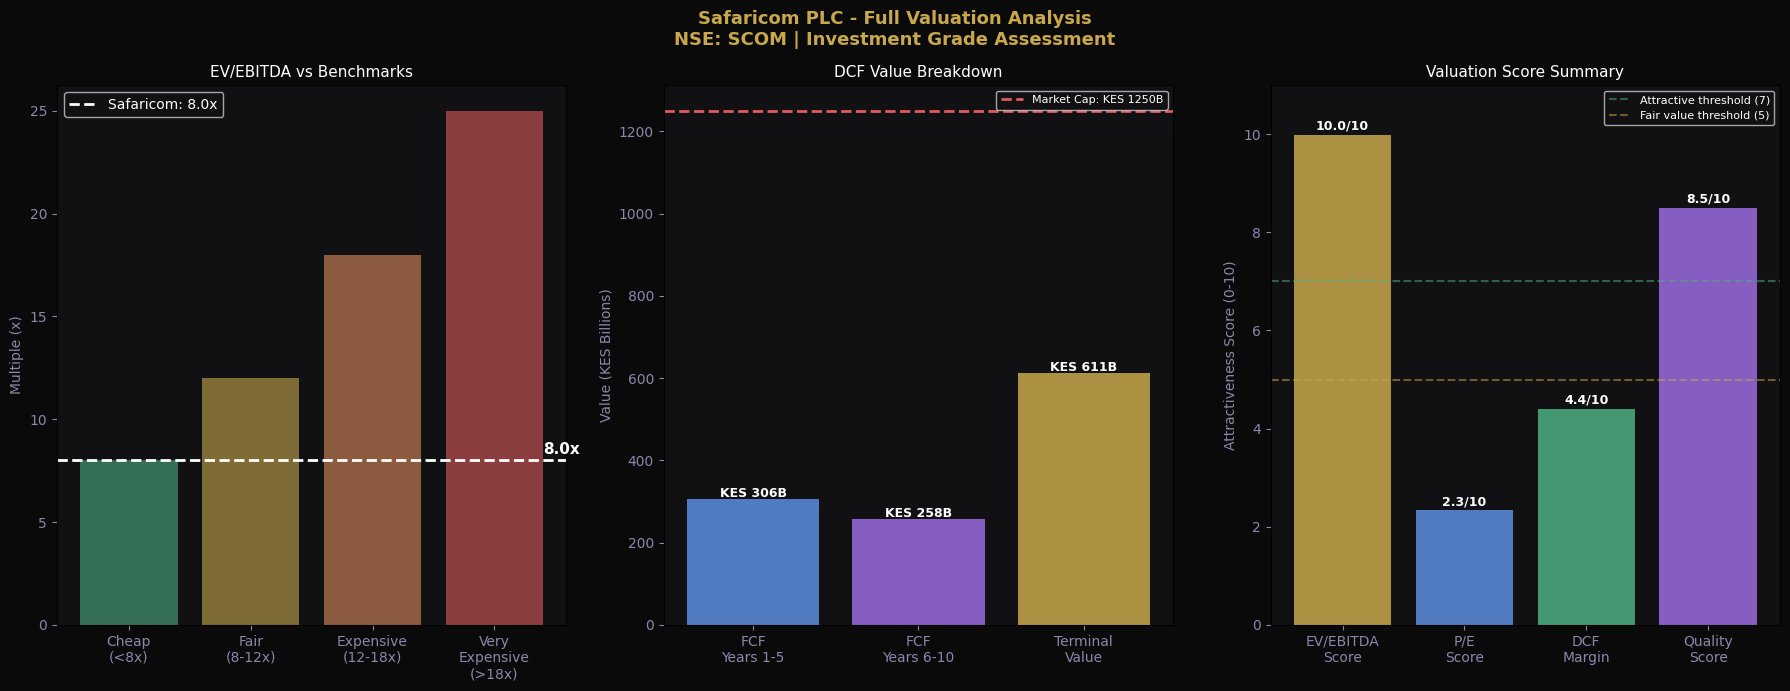

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0A0A0B')

# - LEFT: EV/EBITDA gauge
ax1 = axes[0]
benchmarks  = ['Cheap\n(<8x)', 'Fair\n(8-12x)',
               'Expensive\n(12-18x)', 'Very\nExpensive\n(>18x)']
bench_vals  = [8, 12, 18, 25]
bench_cols  = ['#4CAF82', '#C9A84C', '#E08C5C', '#E05C5C']

bars = ax1.bar(benchmarks, bench_vals,
               color=bench_cols, alpha=0.6, edgecolor='none')

# Mark Safaricom
ax1.axhline(y=ev_ebitda, color='white',
            linewidth=2, linestyle='--',
            label=f'Safaricom: {ev_ebitda:.1f}x')
ax1.text(3.4, ev_ebitda + 0.3,
         f'{ev_ebitda:.1f}x', color='white',
         fontsize=11, fontweight='bold')

ax1.set_facecolor('#111114')
ax1.set_title('EV/EBITDA vs Benchmarks',
              color='white', fontsize=11)
ax1.set_ylabel('Multiple (x)', color='#8888AA')
ax1.tick_params(colors='#8888AA')
ax1.legend(facecolor='#111114', labelcolor='white')

# - MIDDLE: DCF waterfall
ax2 = axes[1]
dcf_components = {
    'FCF\nYears 1-5':   sum(fcf * 1/(1.12**y)
                            for y, fcf in
                            enumerate(projected_fcf[:5], 1)),
    'FCF\nYears 6-10':  sum(fcf * 1/(1.12**y)
                            for y, fcf in
                            enumerate(projected_fcf[5:], 6)),
    'Terminal\nValue':   pv_terminal
}

comp_colors = ['#5C8EE0', '#9B6BE0', '#C9A84C']
bars2 = ax2.bar(
    dcf_components.keys(),
    [to_billions(v) for v in dcf_components.values()],
    color=comp_colors, alpha=0.85
)
for bar, val in zip(bars2, dcf_components.values()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'KES {to_billions(val):.0f}B',
             ha='center', color='white',
             fontsize=9, fontweight='bold')

ax2.axhline(y=to_billions(market_cap),
            color='#E05C5C', linewidth=2,
            linestyle='--',
            label=f'Market Cap: KES {to_billions(market_cap):.0f}B')

ax2.set_facecolor('#111114')
ax2.set_title('DCF Value Breakdown',
              color='white', fontsize=11)
ax2.set_ylabel('Value (KES Billions)', color='#8888AA')
ax2.tick_params(colors='#8888AA')
ax2.legend(facecolor='#111114', labelcolor='white', fontsize=8)

# - RIGHT: Valuation summary spider/radar
ax3 = axes[2]

metrics     = ['EV/EBITDA\nScore', 'P/E\nScore',
               'DCF\nMargin', 'Quality\nScore']

# Normalise each to 0-10 where 10 = most attractive
ev_score  = max(0, 10 - (ev_ebitda - 8))
pe_score  = max(0, 10 - (pe_ratio - 12) * 0.5)
dcf_score = min(10, max(0, 5 + margin_of_safety / 10))
qual_score = 8.5  # based on 44.3% EBITDA margin + 141% cash conversion

scores_radar = [ev_score, pe_score, dcf_score, qual_score]
colors_radar = ['#C9A84C', '#5C8EE0', '#4CAF82', '#9B6BE0']

bars3 = ax3.bar(metrics, scores_radar,
                color=colors_radar, alpha=0.85)
for bar, val in zip(bars3, scores_radar):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.1f}/10',
             ha='center', color='white',
             fontsize=9, fontweight='bold')

ax3.axhline(y=7, color='#4CAF82', linestyle='--',
            alpha=0.5, label='Attractive threshold (7)')
ax3.axhline(y=5, color='#C9A84C', linestyle='--',
            alpha=0.5, label='Fair value threshold (5)')
ax3.set_ylim(0, 11)
ax3.set_facecolor('#111114')
ax3.set_title('Valuation Score Summary',
              color='white', fontsize=11)
ax3.set_ylabel('Attractiveness Score (0-10)', color='#8888AA')
ax3.tick_params(colors='#8888AA')
ax3.legend(facecolor='#111114', labelcolor='white', fontsize=8)

plt.suptitle(
    'Safaricom PLC - Full Valuation Analysis\n'
    'NSE: SCOM | Investment Grade Assessment',
    color='#C9A84C', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Investment Memo Conclusion: Safaricom PLC (NSE: SCOM)

Safaricom PLC, at its current market capitalization of KES 1.25 trillion, presents as a fairly valued to moderately expensive proposition across key valuation methodologies. The EV/EBITDA multiple of 8.0x suggests the company is **fairly valued**, commanding a premium consistent with a high-quality African telecommunications operator, yet indicating limited immediate upside. Conversely, the P/E ratio of 27.3x positions Safaricom as **very expensive** relative to both NSE and African telecom averages, implying a strong dependency on aggressive future growth to justify its current earnings multiple. The Discounted Cash Flow (DCF) model corroborates a **fairly valued** assessment, yielding a slight negative margin of safety at -5.9%, suggesting limited intrinsic value upside from current levels. Furthermore, the DCF's heavy reliance (51.9%) on the terminal value introduces a notable degree of uncertainty given the long-term assumptions involved. In aggregate, while Safaricom demonstrates strong operational quality, its valuation metrics, particularly the P/E, suggest the market has already priced in significant future growth, leaving a constrained margin of safety for new long-term investors at the prevailing market price.

Qustion Analysis

1. **Safaricom's EV/EBITDA multiple:** The EV/EBITDA multiple for Safaricom is 8.0x, which the analysis concludes is FAIRLY VALUED. It's considered a premium telecom multiple, reflecting quality but with limited upside.

2. **DCF analysis verdict:** The Discounted Cash Flow (DCF) analysis shows a Margin of Safety of -5.9%. This indicates that the market is FAIRLY VALUED at its current price, with limited upside according to the DCF model.

3. **Terminal Value contribution to DCF:** The present value of the terminal value is KES 611 billion, and the total intrinsic value from the DCF is KES 1176 billion. Therefore, approximately 51.9% (611/1176 * 100) of Safaricom's DCF value comes from the terminal value. This number is significant for a long-term investor because a high proportion of value derived from the terminal value implies that a substantial portion of the company's estimated worth depends on assumptions about its perpetual growth far into the future. This introduces a higher degree of uncertainty and sensitivity to growth rate and discount rate assumptions, which can increase the investment risk if those long-term projections do not materialize.

4. **Final Investment Verdict on Safaricom:**

Investment Memo Conclusion: Safaricom PLC (NSE: SCOM)

Safaricom PLC, at its current market capitalization of KES 1.25 trillion, presents as a fairly valued to moderately expensive proposition across key valuation methodologies. The EV/EBITDA multiple of 8.0x suggests the company is fairly valued, commanding a premium consistent with a high-quality African telecommunications operator, yet indicating limited immediate upside. Conversely, the P/E ratio of 27.3x positions Safaricom as very expensive relative to both NSE and African telecom averages, implying a strong dependency on aggressive future growth to justify its current earnings multiple. The Discounted Cash Flow (DCF) model corroborates a fairly valued assessment, yielding a slight negative margin of safety at -5.9%, suggesting limited intrinsic value upside from current levels. Furthermore, the DCF's heavy reliance (51.9%) on the terminal value introduces a notable degree of uncertainty given the long-term assumptions involved. In aggregate, while Safaricom demonstrates strong operational quality, its valuation metrics, particularly the P/E, suggest the market has already priced in significant future growth, leaving a constrained margin of safety for new long-term investors at the prevailing market price.